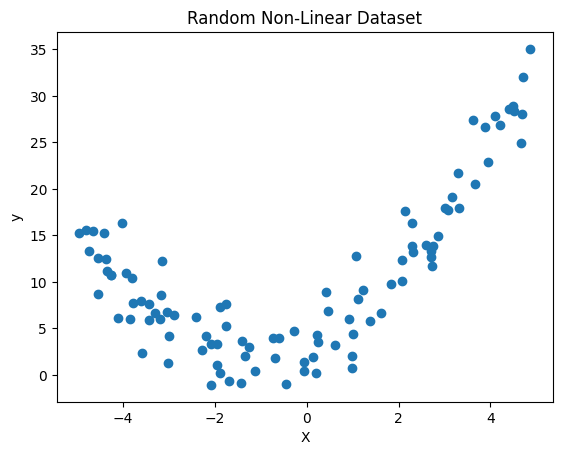

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Random X values
X = np.random.uniform(-5, 5, 100)

# Non-linear relationship + random noise
y = 4 + 2*X + 0.8*(X**2) + np.random.normal(0, 3, 100)

# Reshape X because sklearn expects 2D input
X = X.reshape(-1, 1)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Random Non-Linear Dataset")
plt.show()

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80, 1)
(20, 1)


In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(X_train_poly[:5])

[[ 1.          4.21874235 17.79778702]
 [ 1.          3.87212743 14.9933708 ]
 [ 1.         -3.00326218  9.01958371]
 [ 1.         -4.65611479 21.67940493]
 [ 1.          4.86886937 23.7058889 ]]


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_pred = model.predict(X_test_poly)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.733994533849085
MSE : 5.722565465538726
RMSE: 2.3921884260105277
R²  : 0.904402678583097


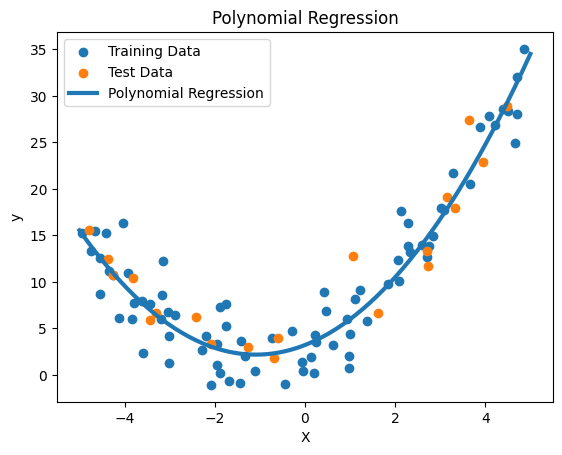

In [7]:
X_curve = np.linspace(-5, 5, 200).reshape(-1, 1)

X_curve_poly = poly.transform(X_curve)

y_curve = model.predict(X_curve_poly)

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Test Data")

plt.plot(X_curve, y_curve, linewidth=3, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()